## Step0: Mounting drive and setting-up directory

In [1]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [2]:
path_to_folder = "ENPM673/Projects/Project1/"
%cd /content/drive/My\ Drive/{path_to_folder}

/content/drive/My Drive/ENPM673/Projects/Project1


In [3]:
# Path verification
!pwd
print("Name - Rahul Kumar")

/content/drive/My Drive/ENPM673/Projects/Project1
Name - Rahul Kumar


## Part1: Reading video and extracting frames

In [4]:
# Importing libraries and dependencies
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [5]:
# Reading video
vid = cv.VideoCapture('Ball_travel_2.mp4')

# Condition To check whther video is read correctly or not
if not vid.isOpened():
    print("Cannot read video")
else:
  print("All good!")

#To count total number of frames in this video
frame_count = vid.get(cv.CAP_PROP_FRAME_COUNT)
print(f"Total Frames: {frame_count}")

All good!
Total Frames: 24.0


In [6]:
# Loop to extract individual frames from the video
frame_present = True
frames = []  # List to store frames
while frame_present:
  frame_present, frame = vid.read()


  # To check if frame is read correctly
  if not frame_present:
      print("Can't receive frame. End of video. Exiting ...")
      break

  # Converting frames from BGR to RGB
  rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
  # Store the frame in the list
  frames.append(rgb_frame)

# When everything done, release the capture
vid.release()

Can't receive frame. End of video. Exiting ...


In [7]:
# Size of frames
print(rgb_frame.shape)
print("Image type: ", type(rgb_frame))
print("Image data type: ", rgb_frame.dtype)

# print(len(frames))
# for i in range(2, 5):
#     plt.imshow(frames[i])
#     plt.show()

(2488, 3520, 3)
Image type:  <class 'numpy.ndarray'>
Image data type:  uint8


## Part2 & Part3: Extracting ball pixels & Calculating Centroid

In [8]:
# Define the range for red color in HSV space
# Lower red spectrum in hsv
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])

# Upper red spectrum in hsv
lower_red2 = np.array([170,50,50])
upper_red2 = np.array([180,255,255])

# List to store centroid values of balls from each frame
x_horiz = []
y_vert = []

# Total number of frames in the video
total_frames = int(frame_count)

# Looping to extract ball pixels and it's centroid
for i in range(0,total_frames):
  # Converting frames from RGB to HSV in order to extract ball pixels
  frames_hsv = cv.cvtColor(frames[i], cv.COLOR_RGB2HSV)

  # Masking all pixels in each frames into black (0) except for red ball pixels(255)
  mask1 = cv.inRange(frames_hsv, lower_red1, upper_red1)    # Masking with lower red color spectrum
  mask2 = cv.inRange(frames_hsv, lower_red2, upper_red2)    # Masking with upper red color spectrum

  # Bitwise OR operation to combine the effect of both red masking
  combined_mask = mask1 | mask2

  # Extracting all white pixel indices of balls
  y_coords, x_coords = np.where(combined_mask == 255)

  # Calculating centroids of ball for each frames
  cx = int(np.mean(x_coords))  # Mean of x-values (columns)
  cy = int(np.mean(y_coords))  # Mean of y-values (rows)

  #appending centroid of ball for each frames
  x_horiz.append(cx)
  y_vert.append(cy)

# print(len(x_horiz),len(y_vert))



## Part4: Curve Fit through centroids

In [9]:
#converting centroid list to numpy array
x_horiz = np.array(x_horiz)
y_vert = np.array(y_vert)

# Ordinary Least Square Fitting
# Assuming parabola of form y = ax^2 + bx + c
# Writing the equation in matrix form Error (E) = Y - XA where A = [a, b, c]^T
# Using Ordinary Least Square Fitting, A = (X^TX)^-1(X^TY)
def ordinary_least_squares(x_horiz, y_vert):
  X = np.vstack((x_horiz**2, x_horiz, np.ones(x_horiz.shape))).transpose()
  X_T_X_Inv = np.linalg.inv(np.matmul(X.transpose(),X))
  X_T_Y = np.matmul(X.transpose(),y_vert)
  A = np.matmul(X_T_X_Inv,X_T_Y)
  return A

# Calling the function to get the parabola equation parameters
eqn_para = ordinary_least_squares(x_horiz, y_vert)

# Extracting equation parameters
a, b, c = eqn_para

# Print the ball trajectory(parabola) equation using ordinary least square fitting method
print(f"The equation of the ball trajectory(parabola) using the least squares method is:")
print(f"y = {a:.4f}x² + {b:.4f}x + {c:.4f}")

#==================================================================================================

# RANSAC method
#  We will be using RANSAC iteration formula N = log(1 - p) / log(1 - (1 - e)^s). p = success probability, s = sample points, e = Outlier ratio
# Selecting number of sample points (s) = 3 for parabola
def ransac_fitting(x_horiz, y_vert, s=3, p=0.99, e=0.8, threshold=0.1): # s = Sample points, p = Success probability, e = Outlier ratio

  N = int(np.log(1 - p) / np.log(1 - np.power((1 - e), s))) # rounding off iterations (N) to integer

  # Variables for inliners
  best_inliers_count = 0
  best_model = None
  best_inliers = None

  # RANSAC iterations
  for i in range(int(N)):
      # Randomly selecting 3 centroid points
      indices = np.random.choice(len(x_horiz), 3, replace=False)    # Randomly selecting 3 indices
      x_sample = x_horiz[indices]                                   # 3 random x points
      y_sample = y_vert[indices]                                    # 3 random y points


      # Fitting the selected points using already defined ordinary least square method
      model = ordinary_least_squares(x_sample, y_sample)

      # Evaluating error band for inliners
      a, b, c = model
      y_pred = a * x_horiz**2 + b * x_horiz + c
      error = np.abs(y_vert - y_pred)


      # Find inliers - those within the threshold error
      inliers = error < threshold

      # Update best model if current model has more inliers
      inliers_count = np.sum(inliers)
      if inliers_count > best_inliers_count:
          best_inliers_count = inliers_count
          best_model = model
          best_inliers = inliers

      # Check if best_model is not computed
      if best_model is None:
        print("Couldn't find the best model")

  return best_model, best_inliers     # returning best model parameters, and best inliners within the band


# Perform RANSAC fitting
best_model, best_inliers = ransac_fitting(x_horiz, y_vert)

# Extract model parameters
if best_model is not None:
    d, e, f = best_model
    # Printing equation for RANSAC
    print(f"The equation of the ball trajectory (parabola) using RANSAC method is:")
    print(f"y = {d:.4f}x² + {e:.4f}x + {f:.4f}")
else:
    print("No valid model found.")


# ransac_fitting(x_horiz, y_vert)

The equation of the ball trajectory(parabola) using the least squares method is:
y = 0.0005x² + -1.6467x + 2450.6571
The equation of the ball trajectory (parabola) using RANSAC method is:
y = 0.0004x² + -1.3391x + 2328.5599


## Part5: Calculating Y for X

In [10]:
# Given x value
x_0 = 1000

# Calculate y_0 for x_0 using least square fitting
y_0 = a * (x_0 ** 2) + b * x_0 + c
print(f"Value of Y corresponding to x = 1000 using ordinary least square fitting = {y_0:.4f}")

# Calculate y_1 for x_0 using RANSAC fitting
y_1 = d * (x_0 ** 2) + e * x_0 + f
print(f"Value of Y corresponding to x = 1000 using RANSAC fitting = {y_1:.4f}")


Value of Y corresponding to x = 1000 using ordinary least square fitting = 1266.7794
Value of Y corresponding to x = 1000 using RANSAC fitting = 1359.8687


## Part6: Plotting curve-fit on the frame

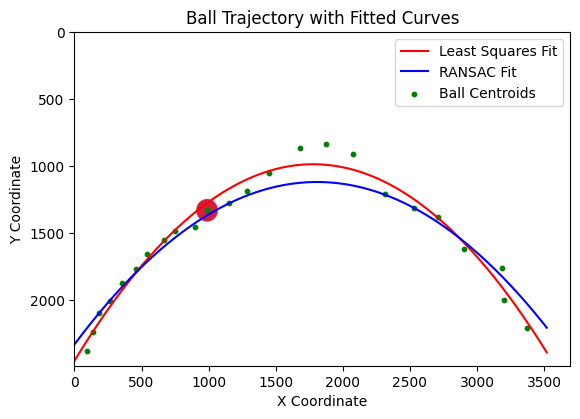

In [11]:
# Choosing 7th Frame for the background image (optional: use any frame as reference)
plot_frame = frames[10]  # Background frame for visualization

# Generating a range of x-values for plotting the fits
x_values = np.linspace(0, plot_frame.shape[1], plot_frame.shape[1])

# Calculating y-values for both Least Squares and RANSAC fits
y_ls = a * (x_values ** 2) + b * x_values + c
y_ransac = d * (x_values ** 2) + e * x_values + f

# Displaying the chosen frame as the background
plt.imshow(plot_frame)

# Plot the Least Squares fit in red
plt.plot(x_values, y_ls, color='red', label="Least Squares Fit")

# Plot the RANSAC fit in blue
plt.plot(x_values, y_ransac, color='blue', label="RANSAC Fit")

# Plot the actual ball centroids from all frames
plt.scatter(x_horiz, y_vert, color='green', s=10, label="Ball Centroids")

# Add a legend
plt.legend()

# Show the plot
plt.title("Ball Trajectory with Fitted Curves")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

**Comparison:**
1. As we can see from the video of moving ball that ball sometimes suddenly jumps inward wrt it's parabolic trajectory. Such points can be counted as outliners, and we can see that RANSAC fitting method captures them as curve is little going below thet Least swuare fit after a moment.

2. We can see that vertical (y) coordinate of ball given by least square fit is given by 1266 (approx), where as RANSAC gives 1304. As it can be seen in the plot above that ball is at x = 1000, which is near to RANSAC trajectory. So, we can say that since this ball video had some outliners, RANSAC fits better than least sqyare fitting in this case.

In [19]:
import cv2 as cv
import numpy as np
import time  # For introducing delays

# Define the output video parameters
output_video_path = "Ball_Trajectory_with_Larger_Labels.mp4"
frame_height, frame_width, _ = frames[0].shape  # Get dimensions from the first frame
fps = 10  # Reduced frame rate (adjust as needed)
fourcc = cv.VideoWriter_fourcc(*'mp4v')  # Codec for MP4 format

# Create a VideoWriter object to save the output video
out = cv.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

# Define font properties for labels
font = cv.FONT_HERSHEY_SIMPLEX
font_scale = 3.0  # Increased font size for better visibility
font_thickness = 5  # Increased thickness for larger font
text_color_red = (0, 0, 255)  # Red for Least Squares Fit
text_color_blue = (255, 0, 0)  # Blue for RANSAC Fit
text_color_green = (0, 0, 0)  # Black for Ball Centroid

# Define positions for the title and legend
title_position = (10, int(60 * font_scale / 2))  # Adjusted position for the title
legend_start_y = int(100 * font_scale / 2)  # Starting y-coordinate for the legend
line_length = int(100 * font_scale / 2)  # Length of the lines in the legend (adjusted for larger font)

# Loop through all frames and overlay the plots and labels
for i in range(len(frames)):
    # Convert the current frame from RGB to BGR (OpenCV uses BGR format)
    frame = cv.cvtColor(frames[i], cv.COLOR_RGB2BGR)

    # Generate x-values for plotting the fits
    x_values = np.linspace(0, frame_width, frame_width)

    # Compute y-values for Least Squares fit
    y_ls = a * (x_values ** 2) + b * x_values + c

    # Compute y-values for RANSAC fit
    y_ransac = d * (x_values ** 2) + e * x_values + f

    # Draw the Least Squares fit (red curve)
    for j in range(len(x_values) - 1):
        x1, y1 = int(x_values[j]), int(y_ls[j])
        x2, y2 = int(x_values[j + 1]), int(y_ls[j + 1])
        if 0 <= y1 < frame_height and 0 <= y2 < frame_height:  # Ensure points are within frame bounds
            cv.line(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)  # Red color

    # Draw the RANSAC fit (blue curve)
    for j in range(len(x_values) - 1):
        x1, y1 = int(x_values[j]), int(y_ransac[j])
        x2, y2 = int(x_values[j + 1]), int(y_ransac[j + 1])
        if 0 <= y1 < frame_height and 0 <= y2 < frame_height:  # Ensure points are within frame bounds
            cv.line(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Blue color

    # Overlay the full ball from previous frames
    for k in range(i):  # Loop through all previous frames up to the current frame
        if k < len(x_horiz):  # Ensure the current frame has a detected centroid
            cx_prev, cy_prev = int(x_horiz[k]), int(y_vert[k])

            # Extract the ball region from the previous frame
            radius = 10  # Approximate radius of the ball
            x_min = max(0, cx_prev - radius)
            x_max = min(frame_width, cx_prev + radius)
            y_min = max(0, cy_prev - radius)
            y_max = min(frame_height, cy_prev + radius)

            # Overlay the ball region onto the current frame
            if x_min < x_max and y_min < y_max:  # Ensure valid region
                ball_region = frames[k][y_min:y_max, x_min:x_max]  # Extract ball region from previous frame
                frame[y_min:y_max, x_min:x_max] = ball_region  # Overlay onto current frame

    # Draw the current ball's centroid (larger green circle)
    if i < len(x_horiz):  # Ensure the current frame has a detected centroid
        cx, cy = int(x_horiz[i]), int(y_vert[i])
        if 0 <= cx < frame_width and 0 <= cy < frame_height:  # Ensure centroid is within frame bounds
            cv.circle(frame, (cx, cy), radius=10, color=(0, 0, 0), thickness=-1)  # Larger green circle for the current centroid

    # Add the title ("Ball Trajectory")
    cv.putText(frame, "Ball Trajectory", title_position, font, font_scale, (255, 255, 255), font_thickness)

    # Add the legend
    # Least Squares Fit
    cv.line(frame, (10, legend_start_y), (10 + line_length, legend_start_y), text_color_red, 5)  # Thicker line
    cv.putText(frame, "Least Squares Fit", (10 + line_length + 10, legend_start_y + int(50 * font_scale / 2)),
               font, font_scale, text_color_red, font_thickness)

    # RANSAC Fit
    cv.line(frame, (10, legend_start_y + int(150 * font_scale / 2)),
            (10 + line_length, legend_start_y + int(150 * font_scale / 2)), text_color_blue, 5)  # Thicker line
    cv.putText(frame, "RANSAC Fit", (10 + line_length + 10, legend_start_y + int(200 * font_scale / 2)),
               font, font_scale, text_color_blue, font_thickness)

    # Ball Centroid
    cv.circle(frame, (10 + line_length // 2, legend_start_y + int(300 * font_scale / 2)),
              radius=int(10 * font_scale / 2), color=text_color_green, thickness=-1)  # Larger dot for legend
    cv.putText(frame, "Ball Centroid", (10 + line_length + 10, legend_start_y + int(350 * font_scale / 2)),
               font, font_scale, text_color_green, font_thickness)

    # Write the modified frame to the output video
    out.write(frame)

    # Duplicate the frame to further slow down the video (optional)
    for _ in range(2):  # Write the same frame 2 additional times
        out.write(frame)

    # Introduce a delay between frames (optional)
    time.sleep(0.05)  # Sleep for 50 milliseconds (adjust as needed)

# Release the VideoWriter and close all windows
out.release()
cv.destroyAllWindows()

print(f"Output video saved at: {output_video_path}")

Output video saved at: Ball_Trajectory_with_Larger_Labels.mp4
